In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

In [11]:
train = pd.read_csv('/Users/hayden/coderepos_mac_mini/mitsui_commodity/data/train.csv')
train = train.set_index('date_id')
train_labels = pd.read_csv('/Users/hayden/coderepos_mac_mini/mitsui_commodity/data/train_labels.csv')
target_pairs = pd.read_csv('/Users/hayden/coderepos_mac_mini/mitsui_commodity/data/target_pairs.csv')

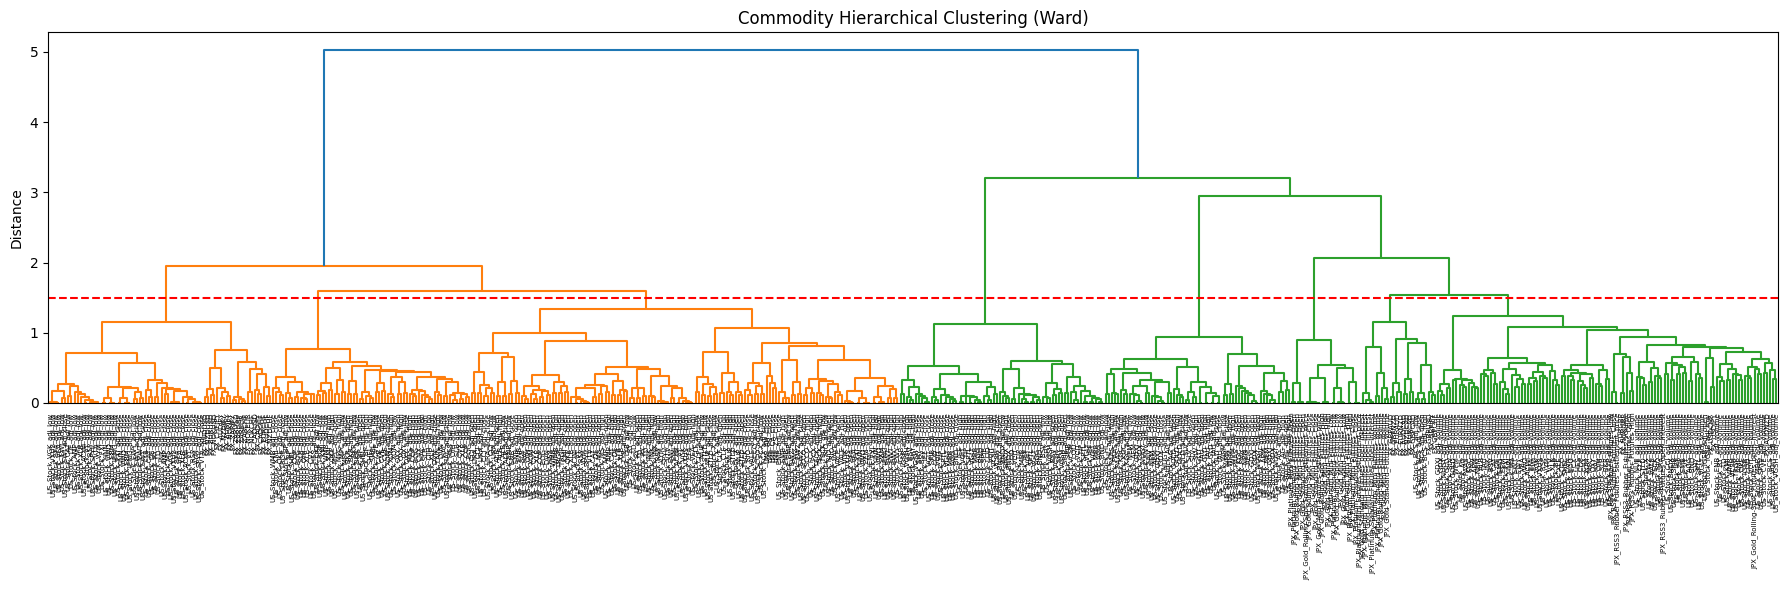

In [16]:
log_returns = np.log(train).diff().dropna()

# correlation -> distance matrix
corr = log_returns.corr()
dist = (1 - corr) / 2  # maps [-1,1] corr to [0,1] distance
dist = np.clip(dist, 0, None)  # fix floating point negatives
condensed = squareform(dist.values, checks=False)

# hierarchical clustering
Z = linkage(condensed, method='ward')

# dendrogram
fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(
    Z,
    labels=log_returns.columns.tolist(),
    leaf_rotation=90,
    ax=ax
)
ax.set_title('Commodity Hierarchical Clustering (Ward)')
ax.set_ylabel('Distance')

ax.axhline(y=1.5, color='red', linestyle='--', label='cut at y=1.5')

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()


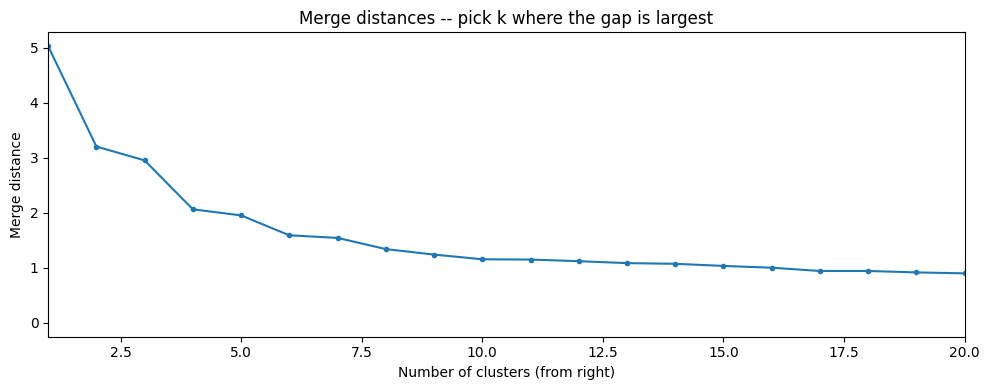

In [14]:
# plot the merge distances to find the biggest gap
merge_distances = Z[:, 2]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(merge_distances) + 1), merge_distances[::-1], marker='o', markersize=3)
ax.set_xlabel('Number of clusters (from right)')
ax.set_ylabel('Merge distance')
ax.set_title('Merge distances -- pick k where the gap is largest')
ax.set_xlim(1, 20)  # zoom into small k range
plt.tight_layout()
plt.savefig('merge_distances.png', dpi=150)
plt.show()

In [17]:

# cut into k clusters -- adjust k after inspecting the dendrogram
k = 9
labels_cluster = fcluster(Z, k, criterion='maxclust')
cluster_df = pd.DataFrame({
    'asset': log_returns.columns,
    'cluster': labels_cluster
}).sort_values('cluster')

#print(cluster_df.to_string(index=False))


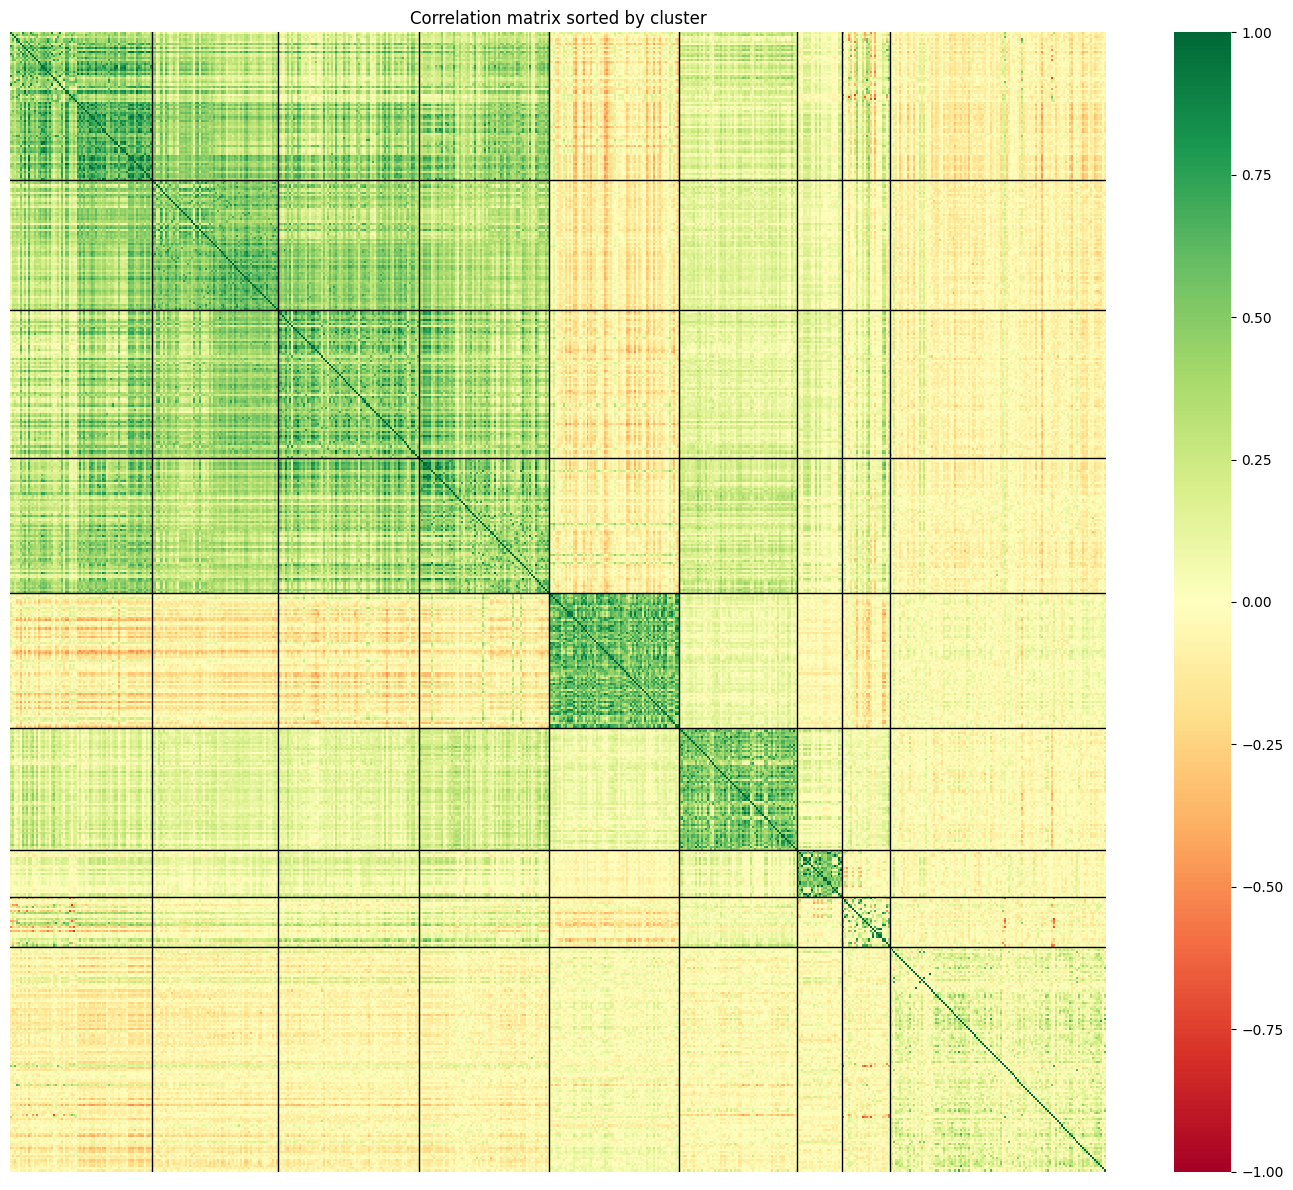

In [22]:
import seaborn as sns

# sort assets by cluster
ordered_assets = cluster_df.sort_values('cluster')['asset'].tolist()
corr_sorted = corr.loc[ordered_assets, ordered_assets]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_sorted, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False,  # turn off labels entirely
            ax=ax)

# instead, draw lines to show cluster boundaries
sizes = cluster_df.groupby('cluster').size().values
boundaries = np.cumsum(sizes)[:-1]
for b in boundaries:
    ax.axhline(b, color='black', linewidth=1)
    ax.axvline(b, color='black', linewidth=1)

ax.set_title('Correlation matrix sorted by cluster')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150)
plt.show()

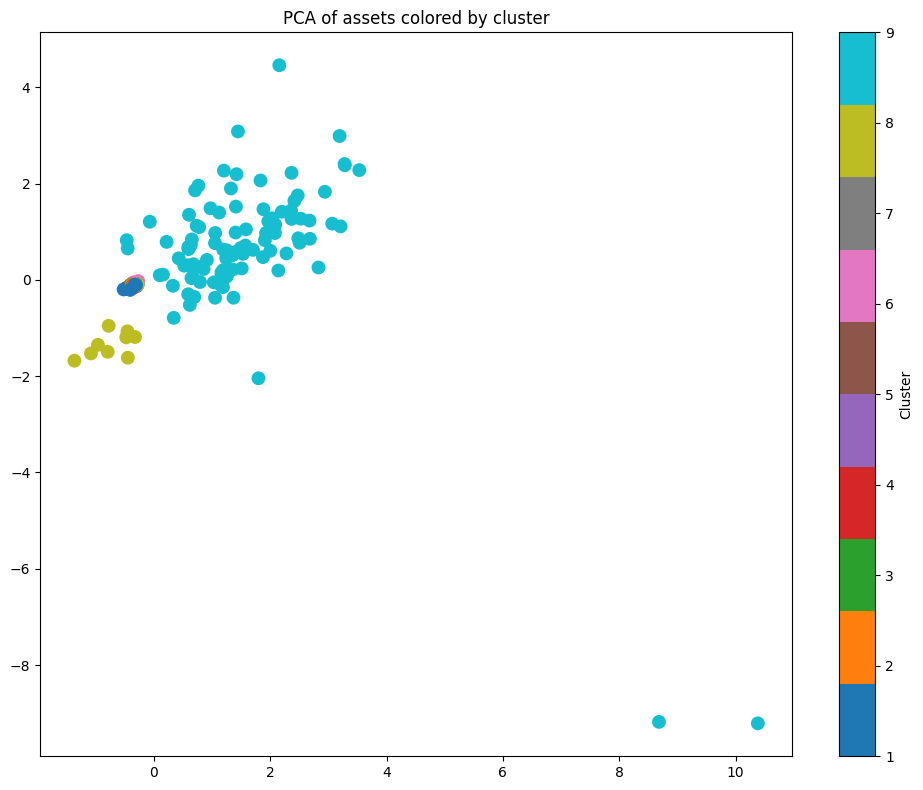

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(log_returns.T)  # assets as rows

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels_cluster, cmap='tab10', s=80)
#for i, asset in enumerate(log_returns.columns):
#    ax.annotate(asset, (coords[i, 0], coords[i, 1]), fontsize=7, ha='right')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title('PCA of assets colored by cluster')
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=150)
plt.show()